# Figures and a self-contained mechanism report

`discopt.mkm` draws the **free-energy diagram** and the **reaction network**, and bundles everything (mechanism table, stoichiometric structure, figures, steady state, degree of rate control, apparent kinetics) into one self-contained HTML report.

In [1]:
%matplotlib inline

In [2]:
import discopt.mkm as mk
from discopt.mkm.examples import co_oxidation
m, reactor = co_oxidation(T=500.0)
m

#,reaction,kinetics,type
1,CO + Pt ⇌ CO∗,"A=10000, Ea=0",reversible
2,O2 + 2 Pt ⇌ 2 O∗,"A=10000, Ea=0",reversible
3,CO∗ + O∗ ⇌ CO2 + 2 Pt,"A=1e+08, Ea=0.7",reversible


In [3]:
sol = mk.solve_steady_state(m, reactor)
CO2 = m._by_name['CO2']

## Free-energy diagram

States (intermediates) and transition states (forward barriers) along the mechanism.

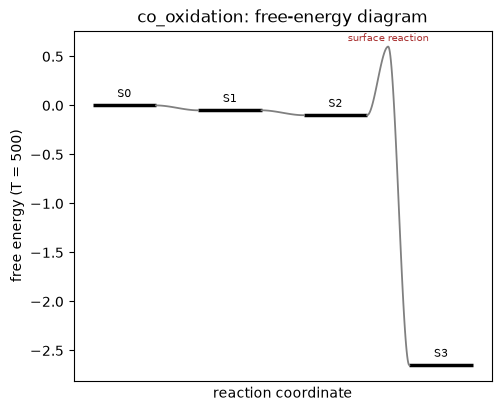

In [4]:
ax = mk.energy_diagram(m)


## Reaction network

The mechanism is a **bipartite graph** with two kinds of nodes:

- **Circles are species.** Gas species (blue), adsorbates (green), and the **catalyst site** itself — here `Pt` (grey). The bare site is a species because adsorption and desorption consume and release it (`CO + Pt ⇌ CO*`), so it gets its own node and its own conservation (site balance).
- **Squares are reactions** — `R1`, `R2`, `R3`, one per elementary step.

Edges run **reactant → reaction → product**. In the static figure below the reaction squares are sized and colored by the net flux (rate of progress) through each step at the solved steady state; in the interactive version further down, the **edge thickness** encodes that flux.

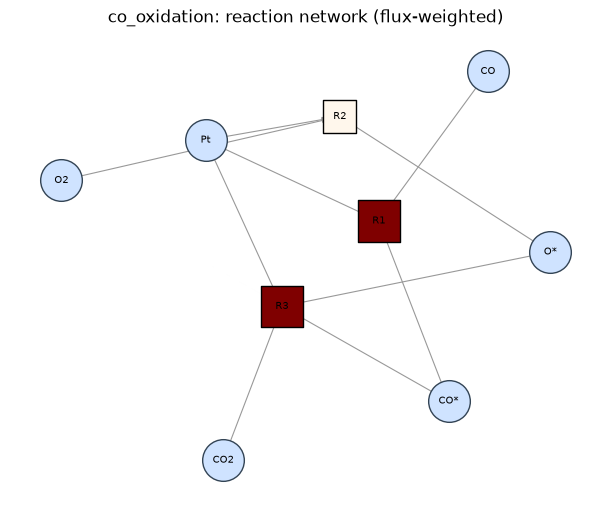

In [5]:
ax = mk.network_graph(m, solution=sol)


Or emit Graphviz DOT for publication-quality layout:

In [6]:
print(mk.to_dot(m)[:300], '...')

digraph "co_oxidation" {
  rankdir=LR;
  node [fontsize=10];
  "CO" [shape=ellipse, style=filled, fillcolor="#cfe3ff"];
  "O2" [shape=ellipse, style=filled, fillcolor="#cfe3ff"];
  "CO2" [shape=ellipse, style=filled, fillcolor="#cfe3ff"];
  "Pt" [shape=ellipse, style=filled, fillcolor="#cfe3ff"];
   ...


## One-call HTML report

`report_html` (or `write_report(..., path)`) assembles the mechanism, structure, figures, steady state, DRC, and apparent orders/barrier into a standalone document.

In [7]:
from IPython.display import HTML
HTML(mk.report_html(m, solution=sol, target=CO2, figures=True))

## Interactive reaction network

The same graph as a draggable [vis-network](https://visjs.org) widget (rendered inside a sandboxed `iframe`, since notebooks strip inline scripts from ordinary cell output). **Drag** nodes to rearrange, **scroll** to zoom, **pan** by dragging the background, and **hover** any node or edge for its details — species coverage, reaction equation / rate constant / net rate, or the edge flux. The **edge thickness scales with the net flux** through each step at the solution. Call `.save('network.html')` to write a standalone file you can open in a browser.

In [8]:
mk.interactive_network(m, solution=sol)

In [9]:
mk.interactive_network(m, solution=sol).save('network.html')

'network.html'